In [1]:
# Import libraries for data handling
import pandas as pd
import numpy as np

# Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [3]:
df = pd.read_csv("insurance.csv")

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
# Shape of dataset (rows, columns)
df.shape

# Column names
df.columns

# Dataset information
df.info()

# Check missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


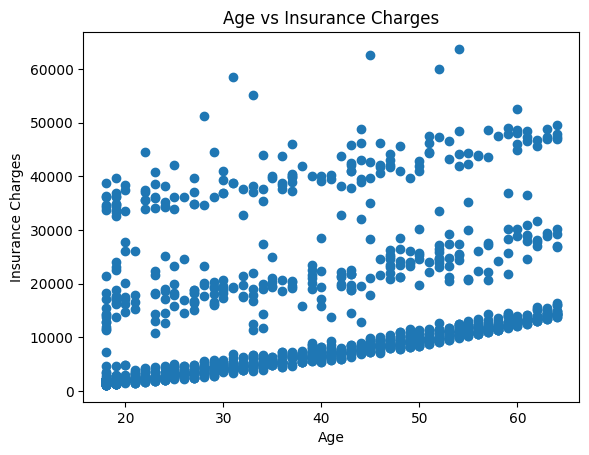

In [6]:
# Scatter plot: Age vs Insurance Charges
plt.scatter(df['age'], df['charges'])
plt.xlabel("Age")
plt.ylabel("Insurance Charges")
plt.title("Age vs Insurance Charges")
plt.show()

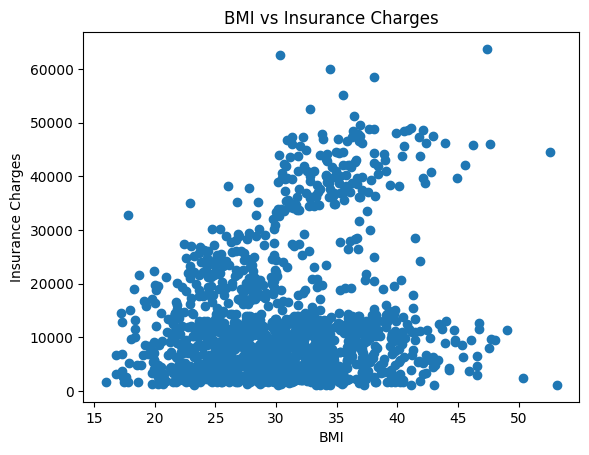

In [7]:
# Scatter plot: BMI vs Charges
plt.scatter(df['bmi'], df['charges'])
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")
plt.title("BMI vs Insurance Charges")
plt.show()

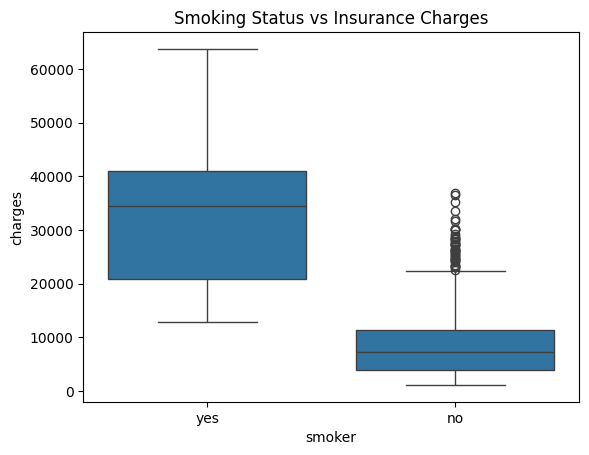

In [8]:
# Boxplot to compare smokers vs non-smokers
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Smoking Status vs Insurance Charges")
plt.show()

In [9]:
# Convert categorical columns into numerical using one-hot encoding
df = pd.get_dummies(df, drop_first=True)

# Display updated dataset
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [10]:
# Features (independent variables)
X = df.drop("charges", axis=1)

# Target variable
y = df["charges"]

In [11]:
# Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
# Create Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

LinearRegression()

In [13]:
# Predict insurance charges
y_pred = model.predict(X_test)

In [14]:
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 4181.19447375365


In [15]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 5796.284659276273


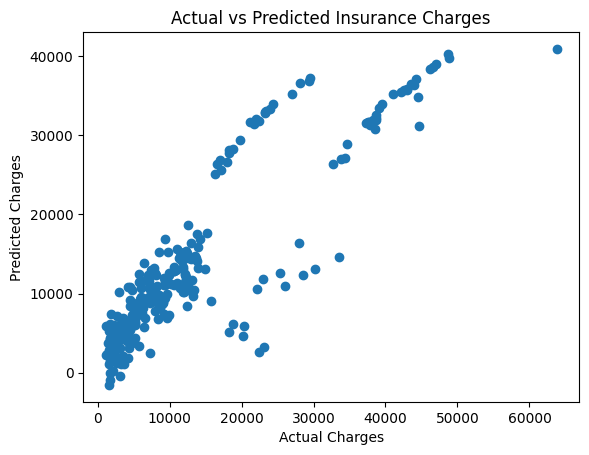

In [16]:
# Compare actual vs predicted charges
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.show()